# Fundamentos de Python para Machine Learning - Análise Exploratória.

Vamos começar este Notebook revisando alguns conceitos que vimos nas aulas anteriores, mas ao mesmo tempo aplicando a um processo de análise de dados, que no final é o que você, residente, mais fará utilizando a lingugem Python no contexto de Big Data e Inteligẽncia Articial na indústria, antes de realizar processos de Machine Learning propriamente ditos.

Nas células seguintes estamos trabalhando com as bibliotecas que conhecemos, mas também com algumas variações de como, por exemplo, calcular estatísticas básicas de alguns dados. Também veremos como imprimir gráficos que nos permitem estudar e visualizar estatísticas sobre nossos dados.

Não se trata ainda de uma aula de um ciclo completo de um projeto de análise e ciência de dados, pois isso você fará na disciplina correspondente da residência. Mas se trata, isso sim, de treinar você no uso de mais ferramentas da linguagem e dos seus Notebooks.

Vamos lá!

### 📌 Antes também é interessante esclarecer alguns significados de palavras importantes. Nossas tabelas tem colunas, que são chamadas de atributos, campos, variáveis ou features.

Primeiro vamos criar nosso dataframe.

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Simulação de dados industriais
np.random.seed(42)  # Reprodutibilidade

num_samples = 100

data = {
    "Idade do Equipamento (anos)": np.random.randint(1, 30, num_samples),
    "Horas Operacionais": np.random.randint(1000, 8000, num_samples),
    "Consumo de Energia (kWh)": np.round(np.random.normal(5000, 1200, num_samples), 1),
    "Temperatura Média (°C)": np.round(np.random.normal(75, 5, num_samples), 1),
    "Pressão Operacional (bar)": np.random.randint(10, 30, num_samples)
}

df = pd.DataFrame(data)

In [2]:
df.head()

,Idade do Equipamento (anos),Horas Operacionais,Consumo de Energia (kWh),Temperatura Média (°C),Pressão Operacional (bar)
0,7,5551,6155.2,88.9,28
1,20,4798,4748.4,74.8,27
2,29,2275,4071.1,74.9,12
3,15,2016,4568.3,76.0,26
4,11,7439,5868.9,78.0,17


Agora vamos conhecer um pouco os dados que geramos. Segue o link da documentação Python: https://docs.python.org/pt-br/3/tutorial/ . Agora da biblioteca de Funções Estatísticas: https://docs.python.org/pt-br/dev/library/statistics.html. Veja que a partir destes links, navegando, você consegue acessar a documentação completa. Deixarei por sua conta encontrar e procurar as informações sobre as demais bibliotecas novas.

Vamos para os próximos códigos.

In [3]:
# Estatísticas
media_energia = df["Consumo de Energia (kWh)"].mean()
moda_energia = stats.mode(df["Consumo de Energia (kWh)"], keepdims=True).mode[0]
desvio_energia = df["Consumo de Energia (kWh)"].std()

print(f"Média do consumo: {media_energia:.2f} kWh")
print(f"Moda do consumo: {moda_energia} kWh")
print(f"Desvio padrão do consumo: {desvio_energia:.2f} kWh")

Média do consumo: 5054.10 kWh
Moda do consumo: 2672.1 kWh
Desvio padrão do consumo: 1216.49 kWh


In [4]:
df.describe()

,Idade do Equipamento (anos),Horas Operacionais,Consumo de Energia (kWh),Temperatura Média (°C),Pressão Operacional (bar)
count,100.000000,100.000000,100.000000,100.000000,100.000000
mean,15.720000,4802.420000,5054.097000,74.853000,20.050000
std,8.596546,2111.205119,1216.494469,4.822201,5.560276
min,1.000000,1064.000000,2672.100000,63.400000,10.000000
25%,8.000000,2959.500000,4131.325000,71.700000,15.000000
50%,15.500000,4938.500000,5007.400000,74.350000,20.000000
75%,23.000000,6752.750000,5955.550000,77.725000,25.250000
max,29.000000,7938.000000,8673.300000,88.900000,29.000000


E agora vamos para nossa primeria visualização.

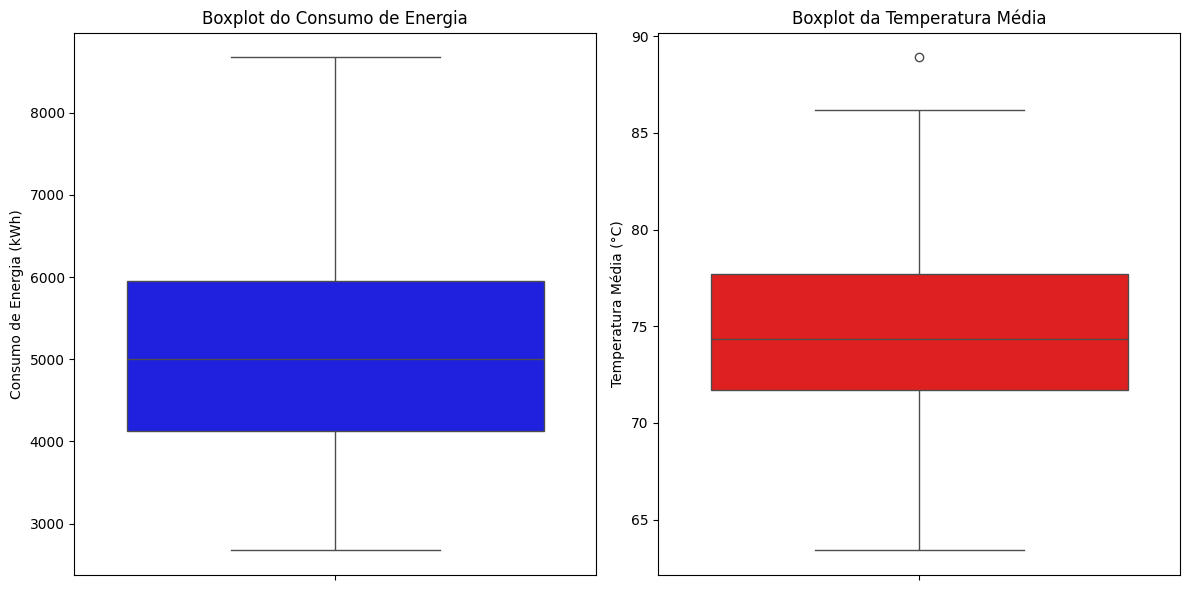

In [ ]:
# Boxplots - Mostra a posição central e a dispersão dos dados, além de possíveis outliers
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(y=df["Consumo de Energia (kWh)"], color="blue")
plt.title("Boxplot do Consumo de Energia")

plt.subplot(1, 2, 2)
sns.boxplot(y=df["Temperatura Média (°C)"], color="red")
plt.title("Boxplot da Temperatura Média")

plt.tight_layout()
plt.show()

Os boxsplots são gráficos que nos ajudam a analisar a distribuição dos dados e seus quartis. Estamos na verdade fazendo uma análise exploratória dos dados.

## 🔍 Análise Exploratória e Multivariada de Dados Industriais

A análise exploratória de dados (EDA, do inglês Exploratory Data Analysis) é a etapa inicial e fundamental em qualquer projeto de ciência de dados. Seu objetivo é compreender a estrutura dos dados, identificar padrões, detectar anomalias (outliers), avaliar distribuições e gerar hipóteses. No contexto industrial, a EDA é aplicada para investigar, por exemplo, o consumo de energia, a temperatura média de operação de máquinas, o número de horas operacionais ou o tempo de vida útil dos equipamentos.

Durante a EDA, utilizamos ferramentas como estatísticas descritivas (média, moda, desvio padrão), visualizações gráficas (histogramas, boxplots) e tabelas de frequência para entender o comportamento das variáveis individualmente. Esses métodos ajudam a revelar comportamentos esperados e também desvios que podem indicar falhas, sobrecargas ou necessidade de manutenção.

Já a análise multivariada amplia essa visão ao considerar relacionamentos entre múltiplas variáveis simultaneamente. Utilizando técnicas como matriz de correlação, gráficos de dispersão (pairplots) e análises de agrupamentos ou componentes principais (PCA), é possível identificar dependências, correlações fortes ou redundância entre variáveis.

No ambiente fabril, essa abordagem multivariada pode revelar, por exemplo, que:

- equipamentos com maior idade tendem a consumir mais energia;

- altas temperaturas médias estão associadas a pressões operacionais elevadas;

- certos padrões de consumo podem ser preditores de falhas futuras.

Ao combinar a EDA com análises multivariadas, criamos uma base sólida para decisões baseadas em dados, diagnóstico de problemas e desenvolvimento de modelos preditivos robustos.

### 📌 Veja que são atividades fortemente relacionadas com uso de estatística básica, utilizando conceitos que já vimos como média, desvio padrão, moda, distribuição, dentre outros.

Este pequena explicação nos era necessária para entender o próximo passo. Adicionei propositadante outliers.

In [5]:
# Adição de outliers
data_outliers = {
    "Idade do Equipamento (anos)": np.random.randint(1, 30, num_samples),
    "Horas Operacionais": np.random.randint(1000, 8000, num_samples),
    "Consumo de Energia (kWh)": np.append(np.random.normal(5000, 1200, num_samples - 5), [10000, 12000, 9500, 11000, 9800]),
    "Temperatura Média (°C)": np.append(np.random.normal(75, 5, num_samples - 5), [100, 102, 105, 98, 99]),
    "Pressão Operacional (bar)": np.random.randint(10, 30, num_samples)
}

In [6]:
df_outliers = pd.DataFrame(data_outliers)

Agora vocẽ pode gerar um novo boxplot e verificar o efeito dos outliers nele. Vou seguir como uma atividade que seria muito comum e um cenário real, a limpeza do dataframe.

In [7]:
# Função para remover outliers
def remover_outliers(df, coluna):
    Q1 = df[coluna].quantile(0.25)
    Q3 = df[coluna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    return df[(df[coluna] >= limite_inf) & (df[coluna] <= limite_sup)]

# Remoção de outliers
df_clean = df_outliers.copy()
df_clean = remover_outliers(df_clean, "Consumo de Energia (kWh)")
df_clean = remover_outliers(df_clean, "Temperatura Média (°C)")

In [8]:
# Estatísticas pós-limpeza
print(f"Registros antes da limpeza: {len(df_outliers)}")
print(f"Registros após a limpeza: {len(df_clean)}")

Registros antes da limpeza: 100
Registros após a limpeza: 94


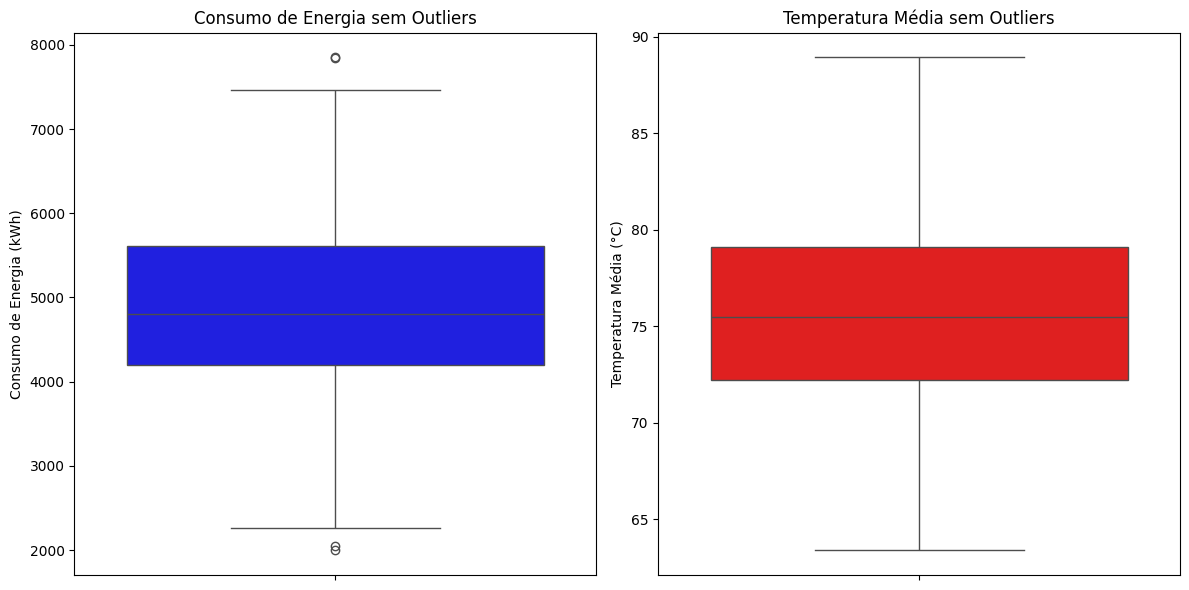

In [9]:
# Boxplot após remoção
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(y=df_clean["Consumo de Energia (kWh)"], color="blue")
plt.title("Consumo de Energia sem Outliers")

plt.subplot(1, 2, 2)
sns.boxplot(y=df_clean["Temperatura Média (°C)"], color="red")
plt.title("Temperatura Média sem Outliers")

plt.tight_layout()
plt.show()

O boxplot (ou diagrama de caixa) é uma representação gráfica que resume a distribuição de um conjunto de dados com base em seus quartis, permitindo uma visualização clara da variação, da presença de outliers (valores extremos) e da simetria dos dados. Ele mostra a mediana (Q2) como uma linha no centro da caixa, e os quartis inferiores (Q1) e superiores (Q3) como as bordas da caixa, representando o intervalo interquartil (IQR = Q3 − Q1), que concentra 50% dos dados centrais. As “linhas” que se estendem a partir da caixa, chamadas de bigodes, indicam a extensão dos dados que ainda são considerados normais, geralmente até 1,5 vezes o IQR. Valores que caem fora desse intervalo são marcados como outliers. O boxplot é uma ferramenta essencial para análises exploratórias, pois revela rapidamente assimetrias, dispersões e possíveis anomalias na distribuição de dados, sem depender de suposições sobre sua forma.

### Quartil

A palavra quartil vem do latim quartus, que significa "quarto", e é usada em estatística para dividir um conjunto de dados ordenado em quatro partes iguais, cada uma contendo aproximadamente 25% dos dados. Existem três quartis principais:

Primeiro quartil (Q1): é o valor que separa os 25% menores dados dos 75% restantes — ou seja, 25% dos valores são menores ou iguais a Q1.

Segundo quartil (Q2): é a mediana, o valor central que divide o conjunto ao meio — 50% dos dados estão abaixo e 50% acima.

Terceiro quartil (Q3): é o valor que separa os 75% menores dados dos 25% restantes — ou seja, 75% dos valores estão abaixo ou iguais a Q3.

A distância entre o terceiro e o primeiro quartil (Q3 − Q1) é chamada de intervalo interquartil (IQR) e é usada para medir a dispersão central dos dados e detectar valores extremos (outliers). O conceito de quartil é fundamental na estatística descritiva e na análise gráfica, como nos boxplots.

## 🔗 Correlação entre Variáveis e Visualização com Heatmap

A correlação é uma medida estatística que expressa o grau de associação linear entre duas variáveis. Quando duas variáveis tendem a variar juntas — como o aumento da temperatura de um equipamento e seu consumo de energia — dizemos que elas estão correlacionadas.

Em análise de dados, especialmente em contextos industriais, calcular a correlação entre variáveis permite detectar relações úteis, como:

- Equipamentos que consomem mais energia conforme a produção aumenta;

- Máquinas que operam sob maior pressão quando em alta temperatura;

- Redução de eficiência quando a idade do equipamento aumenta.

Para visualizar todas as correlações possíveis entre variáveis quantitativas de um conjunto de dados, utilizamos a matriz de correlação. Ela mostra, em formato tabular, os coeficientes de correlação de Pearson (por padrão) entre pares de colunas.

Para facilitar a interpretação, aplicamos um heatmap (mapa de calor) sobre essa matriz. Cores mais fortes indicam correlações mais próximas de -1 ou +1:

- +1: correlação positiva perfeita;

- -1: correlação negativa perfeita;

- 0: nenhuma correlação linear.

O heatmap permite identificar rapidamente relações fortes ou fracas entre variáveis, o que é essencial antes de construir modelos preditivos ou aplicar algoritmos de aprendizado de máquina.

⚠️ Importante: Correlação não implica causalidade. Mesmo que duas variáveis estejam fortemente correlacionadas, isso não significa que uma causa a outra. Fatores externos ou variáveis ocultas podem estar influenciando ambas. Por isso, a interpretação de correlações deve sempre ser acompanhada de conhecimento do domínio e investigação mais profunda.

Agora podemos seguir para a próxima etapa.

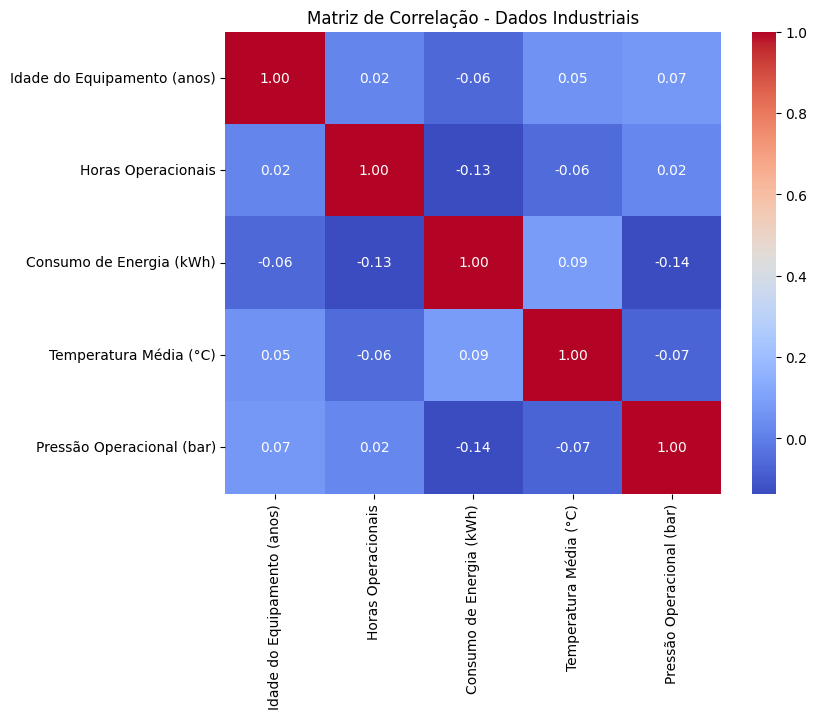

In [10]:
# Heatmap de correlação
correlacao = df_clean.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(correlacao, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação - Dados Industriais")
plt.show()

Nitidamente as correlações dos dados que geramos - nossa tabela era aleatória e apenas para aprendermos a utilizar a linguagem - são muito baixas. A mais forte (-0.14) era entre a "Pressão Operacional" e o "Consumo de Energia". Isso obviamente é um cenário hipotético.

Vamos agora conhecer outra ferramenta de análise. Veja a próxima célula de dados.

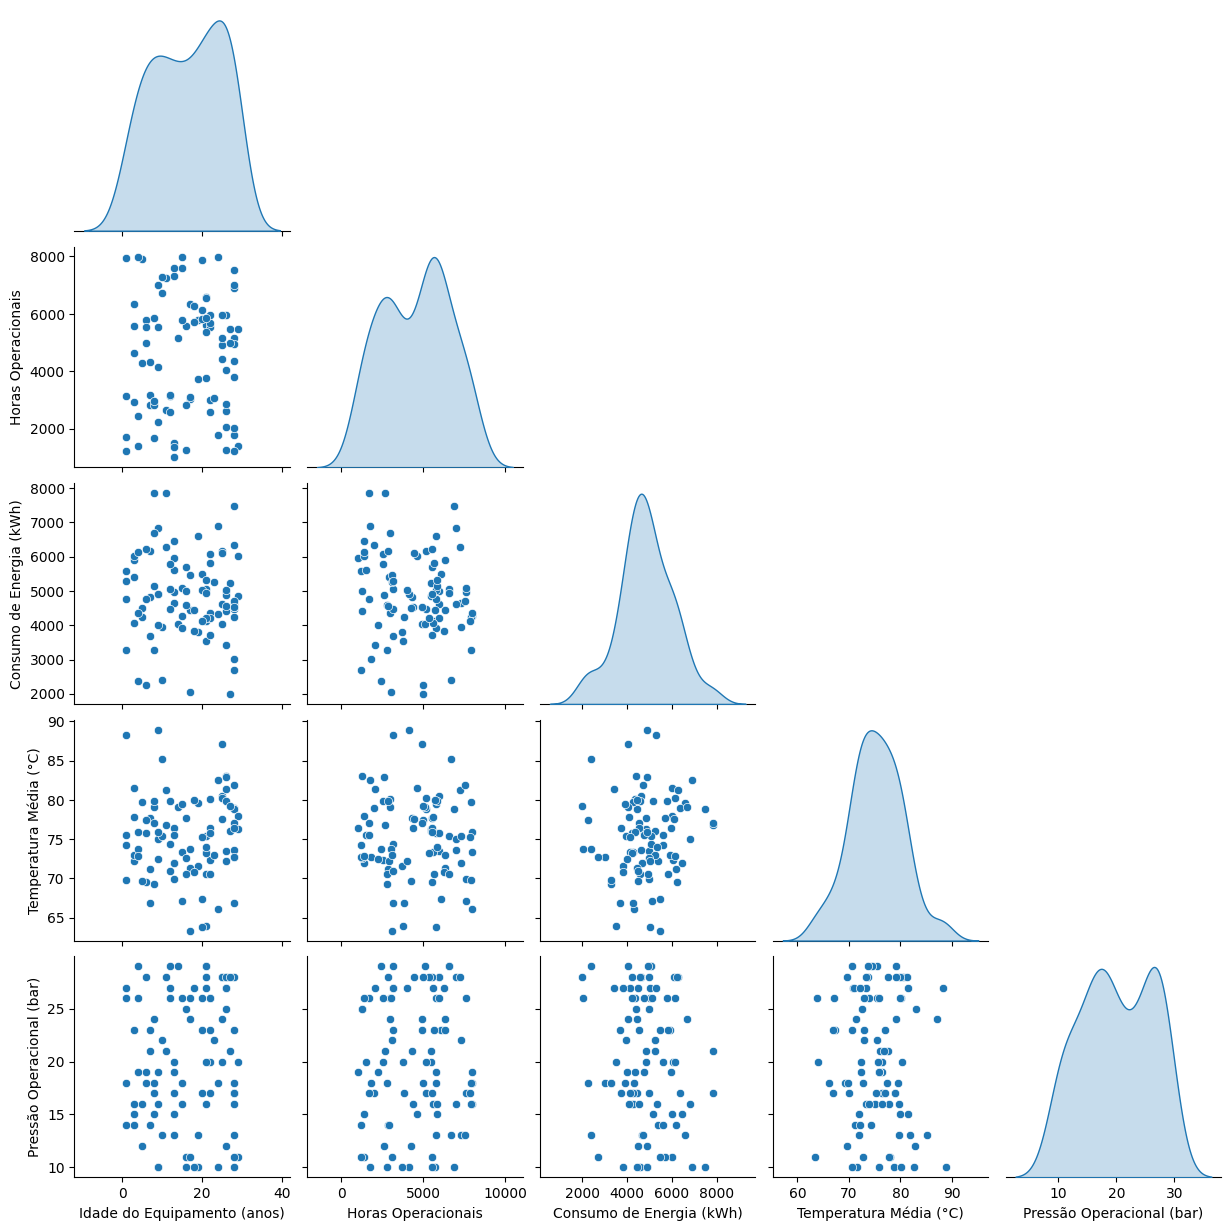

In [11]:
# Gráficos de dispersão
sns.pairplot(df_clean, diag_kind='kde', corner=True)
plt.show()

## 📈 Gráficos de Dispersão: O que são e para que servem?
Os gráficos de dispersão, também conhecidos como scatter plots, são representações gráficas bidimensionais que mostram a relação entre duas variáveis quantitativas. Cada ponto no gráfico representa uma observação do conjunto de dados, com uma coordenada no eixo X (variável independente) e uma no eixo Y (variável dependente ou associada).

###🔍 Para que servem?

Esses gráficos são extremamente úteis em análise exploratória de dados, pois permitem:

- Visualizar tendências ou padrões de associação entre variáveis;

- Identificar correlações (positiva, negativa ou ausência de correlação);

- Detectar outliers (valores discrepantes que se afastam da tendência geral);

- Avaliar a linearidade da relação entre as variáveis;

- Explorar agrupamentos ou separações naturais no conjunto de dados.

###Exemplos

Imagine que estamos analisando dados de um parque fabril. Um gráfico de dispersão entre “Temperatura do Equipamento” (eixo X) e “Consumo de Energia” (eixo Y) pode mostrar:

- Um padrão ascendente → indicando que o consumo aumenta com a temperatura;

- Um padrão caótico → sugerindo que não há relação direta entre as variáveis;

- Outliers → talvez máquinas com problemas de desempenho.

###✅ Interpretações possíveis
- Correlação positiva: pontos se agrupam em uma linha ascendente (quanto maior X, maior Y);

- Correlação negativa: pontos se agrupam em linha descendente (quanto maior X, menor Y);

- Correlação nula: pontos dispersos sem padrão aparente;

- Não linearidade: relação curva, exponencial ou complexa entre as variáveis.

## 📊 Perfis Exploratórios com ydata_profiling e Sweetviz

Durante a etapa de análise exploratória de dados (EDA), é essencial obter uma visão geral rápida e completa sobre o comportamento das variáveis de um DataFrame. Para isso, ferramentas como ydata_profiling e Sweetviz automatizam a geração de relatórios interativos e visuais que economizam tempo e facilitam a compreensão dos dados.

### 🔍 ydata_profiling.ProfileReport

O ydata_profiling (antigo pandas-profiling) é uma das ferramentas mais completas para gerar relatórios estatísticos detalhados. Ele oferece:

Estatísticas descritivas (média, mediana, desvio padrão);

Detecção automática de valores ausentes e duplicados;

Distribuições e histogramas por variável;

Matriz de correlação entre variáveis;

Alertas para possíveis problemas nos dados (como cardinalidade alta ou colunas constantes).

Com apenas uma linha de código, é possível obter um relatório navegável diretamente no Jupyter Notebook:

```python
from ydata_profiling import ProfileReport
profile = ProfileReport(df, title="Relatório Exploratória", explorative=True)
profile.to_notebook_iframe()
```

### 🎨 Sweetviz

O Sweetviz é uma alternativa com foco visual, ideal para comparação entre conjuntos de dados (ex: treino vs teste), além de análise univariada. Ele oferece:

Gráficos interativos e coloridos para cada variável;

Comparações de distribuição entre dois DataFrames;

Destaques automáticos para variáveis mais informativas;

Exportação em HTML navegável.

Uso típico:

```python
import sweetviz as sv
relatorio = sv.analyze(df)
relatorio.show_html("analise_sweetviz.html")
```

### ✅ Quando usar cada um?

| **Objetivo**                             | **Ferramenta sugerida** |
|------------------------------------------|--------------------------|
| Visão estatística profunda               | `ydata_profiling`        |
| Apresentação visual e comparações        | `Sweetviz`               |

Ambas as bibliotecas são valiosas para detectar anomalias, padrões, outliers e correlações ainda na fase inicial da análise, garantindo decisões mais informadas ao longo do projeto.

Então vamos aplicar as duas formas nas células a seguir. Se não funcionar pode ser que vocẽ tenha de instalar as bibliotecas. Lembre-se do "pip install" que vimos nas aulas anteriores.

In [12]:
%pip install ydata_profiling

  Using cached pyyaml-6.0.3-cp312-cp312-win_amd64.whl.metadata (2.4 kB)
  Using cached filetype-1.2.0-py2.py3-none-any.whl.metadata (6.5 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.0 MB 5.6 MB/s eta 0:00:02
   ------ --------------------------------- 1.3/8.0 MB 3.7 MB/s eta 0:00:02
   ---------- ----------------------------- 2.1/8.0 MB 3.4 MB/s eta 0:00:02
   ------------- -------------------------- 2.6/8.0 MB 3.6 MB/s eta 0:00:02
   --------------- ------------------------ 3.1/8.0 MB 3.3 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.0 MB 3.3 MB/s eta 0:00:02
   ----------------------- ---------------- 4.7/8.0 MB 3.3 MB/s eta 0:00:02
   --------------------------- ------------ 5.5/8.0 MB 3.3 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.0 MB 3.2 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.0 MB 3.3 MB/s eta 0:00:01
   ---------------------------

ERROR: Could not install packages due to an OSError: [WinError 5] Acesso negado: 'c:\\users\\fabio\\appdata\\roaming\\python\\python312\\site-packages\\matplotlib\\backends\\_backend_agg.cp312-win_amd64.pyd'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Não deixe de observar que o Profile Report gera, na verdade, um ambiente Web navegável com páginas e menus que podemos explorar para conhecer sobre nossos dados.

In [ ]:
# Perfil com YData Profiling
from ydata_profiling import ProfileReport
profile = ProfileReport(df_clean, title="Relatório Industrial com YData", explorative=True)
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 5/5 [00:00<00:00, 247.12it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [13]:
%pip install sweetviz

  Using cached matplotlib-3.11.1-cp312-cp312-win_amd64.whl.metadata (80 kB)
Using cached matplotlib-3.11.1-cp312-cp312-win_amd64.whl (9.3 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


                                             |          | [  0%]   00:00 -> (? left)

AttributeError: module 'numpy' has no attribute 'VisibleDeprecationWarning'

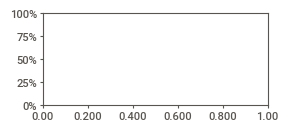

In [ ]:
# Perfil com Sweetviz
import sweetviz as sv
report = sv.analyze(df_clean)
report.show_html("relatorio_industrial_sweetviz.html")

⚠️ Aviso Técnico: Problema de Incompatibilidade entre Sweetviz e NumPy

Durante a execução do comando sv.analyze(df) da biblioteca Sweetviz, você pode se deparar com um erro do tipo:

```python
AttributeError: module 'numpy' has no attribute 'VisibleDeprecationWarning'
```

Esse erro ocorre porque a biblioteca Sweetviz tenta acessar um atributo chamado VisibleDeprecationWarning da biblioteca NumPy — uma função interna usada para emitir avisos sobre uso de práticas desatualizadas.

Contudo, a partir da versão 1.24, o NumPy removeu esse atributo do seu código-fonte. Isso causou incompatibilidade com bibliotecas que ainda dependem dele, como é o caso do Sweetviz.

Softwares como Pandas, NumPy, Sweetviz e outros são desenvolvidos separadamente. Às vezes, mudanças feitas em uma biblioteca não são acompanhadas imediatamente pelas outras. Esse tipo de falha é comum quando bibliotecas:

Dependem de funções internas que não são parte da “interface oficial” (como é o caso dos warnings internos do NumPy);

Não atualizam seus códigos com frequência compatível com grandes mudanças nas bibliotecas que utilizam.

Como resolver?
A solução mais segura atualmente é fazer o downgrade do NumPy para a última versão que ainda contém o atributo necessário (geralmente 1.23.5), garantindo assim a compatibilidade com o Sweetviz.

```python
!pip install numpy==1.23.5
```

Depois disso, reinicie o ambiente de execução para que a nova versão do NumPy entre em vigor, e então instale ou execute novamente o Sweetviz:

```python
!pip install sweetviz --upgrade
```

📌 Nota para os alunos

Esse tipo de erro é muito comum em ambientes científicos e de análise de dados, onde muitas bibliotecas precisam "cooperar" entre si. Saber interpretar essas mensagens e identificar se é um problema de compatibilidade ou de lógica de código é uma habilidade essencial para analistas, cientistas de dados e engenheiros.

## Um pouco mais sobre Análise Multivariada

Durante uma análise de dados industriais, é comum que se comece com a exploração de variáveis isoladas, como o consumo médio de energia de cada equipamento ou a média de produção por turno. No entanto, é na análise multivariada que surgem os insights mais ricos, pois ela permite observar relações entre múltiplas variáveis ao mesmo tempo. A partir dessas relações, surgem hipóteses explicativas que podem ser testadas com abordagens estatísticas ou modelos preditivos.

Por exemplo, imagine que ao cruzar os dados de produção, consumo de energia e temperatura de operação de diferentes máquinas, perceba-se que altas temperaturas estão frequentemente associadas a quedas na produção e aumentos no consumo energético. Essa observação levanta uma hipótese: “Máquinas operando acima de 85 °C têm desempenho ineficiente e geram desperdício de energia”. Essa hipótese pode ser verificada com visualizações (gráficos de dispersão), análise de correlação e segmentação dos dados com agrupamentos, como groupby() e agg() no Pandas.

Com a hipótese formulada, parte-se para o desenvolvimento de análises direcionadas, como testar se a produção média realmente cai em temperaturas elevadas, ou se o desvio padrão do consumo aumenta nessas faixas. Também é possível construir um modelo preditivo para estimar a produção com base na temperatura e outros fatores operacionais, como o tipo de equipamento e o turno de funcionamento.

A hipótese, mesmo quando não confirmada, orienta a análise e permite ajustar o foco da investigação. Em ciência de dados, ela serve como uma ponte entre a observação empírica e a construção de modelos explicativos ou preditivos. Além disso, hipóteses bem fundamentadas ajudam a comunicar resultados com clareza para a equipe técnica e a gestão da empresa, apoiando decisões baseadas em evidências.

Assim, a análise multivariada não apenas revela padrões ocultos nos dados, mas também impulsiona o ciclo de descoberta e refinamento de conhecimento. Ela transforma dados brutos em raciocínio analítico, capaz de guiar ações estratégicas — seja otimizando o uso de recursos, prevenindo falhas ou melhorando a eficiência de processos industriais.

Pesquise mais sobre análise multivariada, vale á pena.

Que tal anotar aqui mesmo no seu Notebook os resultados destas pesquisa?

Clique duas vezes aqui e comece!

## 📦 Os Datasets do Scikit-learn

O Scikit-learn é uma das bibliotecas mais populares de Machine Learning em Python, e uma das suas grandes vantagens para iniciantes e para testes rápidos é a disponibilização de conjuntos de dados prontos para uso. Esses conjuntos, conhecidos como datasets, são ideais para praticar algoritmos, treinar modelos, comparar desempenhos e entender conceitos fundamentais.

Esses datasets estão disponíveis diretamente no módulo sklearn.datasets e podem ser divididos em dois tipos principais:

Datasets Pequenos e Embutidos: São conjuntos de dados clássicos e pequenos, carregados diretamente na memória com funções como load_iris(), load_diabetes(), load_breast_cancer() ou load_digits(). Esses dados são amplamente usados em tutoriais e publicações, pois representam problemas reais simplificados e de fácil entendimento.

Datasets Grandes ou para Download: São conjuntos maiores que podem ser baixados automaticamente ao serem solicitados com funções como fetch_california_housing() ou fetch_20newsgroups(). Eles são úteis para testar pipelines mais complexos e para simular aplicações mais próximas da realidade.

Cada dataset é carregado como um objeto especial do Scikit-learn (um Bunch) que funciona como um dicionário. Ele contém os seguintes atributos:

- data: uma matriz NumPy com os dados (ex: características ou variáveis de entrada),

- target: os rótulos ou valores-alvo,

- feature_names: os nomes das colunas (quando disponíveis),

- DESCR: uma descrição detalhada do conjunto de dados.

📌 Exemplos Populares

- load_iris(): famoso conjunto sobre espécies de flores, usado em classificação.

- load_diabetes(): dados médicos para regressão de diagnóstico.

- load_digits(): imagens de dígitos escritos à mão, útil para visão computacional.

- fetch_20newsgroups(): base textual para NLP e classificação de texto.

Esses conjuntos ajudam os alunos a focar no aprendizado dos algoritmos, sem se preocupar inicialmente com a coleta ou limpeza de dados. Além disso, são ótimos para demonstrar visualizações, aplicar modelos como Regressão Logística, KNN, Árvores de Decisão, SVMs e outros, e avaliar a performance com métricas como acurácia, precisão, recall, etc.

Embora você talvez não tenha entendido alguns nomes como Regressão Logística, KNN, Árvores de Decisão e SVM, não se preocupe. Teremos na residência aulas sobre ciência de Dados que o farão compreender isso e suas aplicações.

No momento estamos fazendo uma introdução da Linguagem Python e de seu uso, começando pelas principais bibliotecas.

Documentação do scikit-lear: https://scikit-learn.org/stable/
Leitura sobre o scikit-learn: https://computacaointeligente.com.br/outros/intro-sklearn-part-1/

<div style="text-align: center;">
  <img src="https://media.tenor.com/bQCHJwgCNuMAAAAM/kitten-cat.gif" width="250">
</div>

### Exercícios

Nesta aula faremos exercícios um pouco diferentes. Vou primeiro colar aqui códigos que foram de exercícios de análises multivariadas em outras turmas do UniSENAI. O exercício foi realizado sobre um dataframe que gerei sem considerar contextos industriais. Que tal usar os passos destas análises em novos dataframes? Você pode criar um, uutilizar o mesmo que criamos acima, ou mesmo utilizar datasets do próprio Scikit-learn. Tente não se limitar ao uso do Profile Report. Explore pelo menos 5 dataframes diferentes, realizando análises multivariadas completas, usando todas as ferramentas que vimos no exemplo que postei ou mesmo de outros locais que vocẽ conheça.

Com estas análises, veja se você consegue ficar ciente do que é cada tabela, suas features e as medidas centrais e de dispersão das features (médias, modas, medianas, desvios, quartis). Veja se elas possuem outliers, vazios, dados ausentes. Como estas características auxiliam ou atrapalham sua análise?

Por fim, pesquise sobre o impacto de outliers e dados ausentes em dataframes e seus impactos em análises multivariadas.

Bons estudos.



In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Criando uma tabela fictícia com dados de saúde
np.random.seed(42)  # Para reprodutibilidade

# Gerando dados fictícios
num_samples = 100  # Número de amostras

data = {
    "Idade": np.random.randint(18, 80, num_samples),
    "IMC": np.round(np.random.normal(25, 5, num_samples), 1),
    "Pressao_Sistolica": np.random.randint(100, 180, num_samples),
    "Pressao_Diastolica": np.random.randint(60, 110, num_samples),
    "Atividade_Fisica": np.random.randint(1, 6, num_samples)
}

df = pd.DataFrame(data)

# Média
media_imc = df["IMC"].mean()
media_pressao = df["Pressao_Sistolica"].mean()

print(f"Média do IMC: {media_imc:.2f}")
print(f"Média da Pressão Sistólica: {media_pressao:.2f}")

# Moda
moda_imc = stats.mode(df["IMC"], keepdims=True).mode[0]
moda_pressao = stats.mode(df["Pressao_Sistolica"], keepdims=True).mode[0]

print(f"Moda do IMC: {moda_imc}")
print(f"Moda da Pressão Sistólica: {moda_pressao}")

# Desvio padrão
desvio_padrao_imc = df["IMC"].std()
desvio_padrao_pressao = df["Pressao_Sistolica"].std()

print(f"Desvio Padrão do IMC: {desvio_padrao_imc:.2f}")
print(f"Desvio Padrão da Pressão Sistólica: {desvio_padrao_pressao:.2f}")

# Exibir a tabela completa
import pandas as pd

# Definir a quantidade máxima de linhas e colunas para visualização
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Exibir o DataFrame
print(df)

# Exibir as primeiras 10 linhas
print(df.head(10))

# Exibir as últimas 10 linhas
print(df.tail(10))

# Exibir a tabela no formato mais legível no Jupyter Notebook
from IPython.display import display
display(df)

# Criando gráficos de distribuição
plt.figure(figsize=(12, 5))

# Histograma do IMC
plt.subplot(1, 2, 1)
sns.histplot(df["IMC"], bins=15, kde=True, color="blue")
plt.title("Distribuição do IMC")
plt.xlabel("IMC")
plt.ylabel("Frequência")

# Histograma da Pressão Sistólica
plt.subplot(1, 2, 2)
sns.histplot(df["Pressao_Sistolica"], bins=15, kde=True, color="red")
plt.title("Distribuição da Pressão Sistólica")
plt.xlabel("Pressão Sistólica (mmHg)")
plt.ylabel("Frequência")

# Exibir os gráficos
plt.tight_layout()
plt.show()

# Criando a figura
plt.figure(figsize=(12, 6))

# Boxplot do IMC
plt.subplot(1, 2, 1)
sns.boxplot(y=df["IMC"], color="blue")
plt.title("Boxplot do IMC")
plt.ylabel("IMC")

# Boxplot da Pressão Sistólica
plt.subplot(1, 2, 2)
sns.boxplot(y=df["Pressao_Sistolica"], color="red")
plt.title("Boxplot da Pressão Sistólica")
plt.ylabel("Pressão Sistólica (mmHg)")

# Exibir os gráficos
plt.tight_layout()
plt.show()

# Calculando estatísticas
media_imc = df["IMC"].mean()
moda_imc = stats.mode(df["IMC"], keepdims=True).mode[0]
desvio_padrao_imc = df["IMC"].std()

media_pressao = df["Pressao_Sistolica"].mean()
moda_pressao = stats.mode(df["Pressao_Sistolica"], keepdims=True).mode[0]
desvio_padrao_pressao = df["Pressao_Sistolica"].std()

# Criando a figura
plt.figure(figsize=(12, 6))

# Boxplot do IMC
plt.subplot(1, 2, 1)
sns.boxplot(y=df["IMC"], color="blue")

# Adicionando estatísticas
plt.axhline(media_imc, color='green', linestyle='--', label=f'Média: {media_imc:.2f}')
plt.axhline(moda_imc, color='purple', linestyle=':', label=f'Moda: {moda_imc}')
plt.axhline(media_imc + desvio_padrao_imc, color='orange', linestyle='-.', label=f'+1σ: {media_imc + desvio_padrao_imc:.2f}')
plt.axhline(media_imc - desvio_padrao_imc, color='orange', linestyle='-.', label=f'-1σ: {media_imc - desvio_padrao_imc:.2f}')

plt.title("Boxplot do IMC")
plt.ylabel("IMC")
plt.legend()

# Boxplot da Pressão Sistólica
plt.subplot(1, 2, 2)
sns.boxplot(y=df["Pressao_Sistolica"], color="red")

# Adicionando estatísticas
plt.axhline(media_pressao, color='green', linestyle='--', label=f'Média: {media_pressao:.2f}')
plt.axhline(moda_pressao, color='purple', linestyle=':', label=f'Moda: {moda_pressao}')
plt.axhline(media_pressao + desvio_padrao_pressao, color='orange', linestyle='-.', label=f'+1σ: {media_pressao + desvio_padrao_pressao:.2f}')
plt.axhline(media_pressao - desvio_padrao_pressao, color='orange', linestyle='-.', label=f'-1σ: {media_pressao - desvio_padrao_pressao:.2f}')

plt.title("Boxplot da Pressão Sistólica")
plt.ylabel("Pressão Sistólica (mmHg)")
plt.legend()

# Exibir os gráficos
plt.tight_layout()
plt.show()

# Calculando estatísticas
total_amostras = len(df)  # Número total de registros

media_imc = df["IMC"].mean()
moda_imc = stats.mode(df["IMC"], keepdims=True).mode[0]
desvio_padrao_imc = df["IMC"].std()

media_pressao = df["Pressao_Sistolica"].mean()
moda_pressao = stats.mode(df["Pressao_Sistolica"], keepdims=True).mode[0]
desvio_padrao_pressao = df["Pressao_Sistolica"].std()

# Criando a figura
plt.figure(figsize=(12, 6))

# Boxplot do IMC
plt.subplot(1, 2, 1)
sns.boxplot(y=df["IMC"], color="blue")

# Adicionando estatísticas
plt.axhline(media_imc, color='green', linestyle='--', label=f'Média: {media_imc:.2f}')
plt.axhline(moda_imc, color='purple', linestyle=':', label=f'Moda: {moda_imc}')
plt.axhline(media_imc + desvio_padrao_imc, color='orange', linestyle='-.', label=f'+1σ: {media_imc + desvio_padrao_imc:.2f}')
plt.axhline(media_imc - desvio_padrao_imc, color='orange', linestyle='-.', label=f'-1σ: {media_imc - desvio_padrao_imc:.2f}')

plt.title(f"Boxplot do IMC (n = {total_amostras})")  # Incluindo o total da amostra no título
plt.ylabel("IMC")
plt.legend()

# Boxplot da Pressão Sistólica
plt.subplot(1, 2, 2)
sns.boxplot(y=df["Pressao_Sistolica"], color="red")

# Adicionando estatísticas
plt.axhline(media_pressao, color='green', linestyle='--', label=f'Média: {media_pressao:.2f}')
plt.axhline(moda_pressao, color='purple', linestyle=':', label=f'Moda: {moda_pressao}')
plt.axhline(media_pressao + desvio_padrao_pressao, color='orange', linestyle='-.', label=f'+1σ: {media_pressao + desvio_padrao_pressao:.2f}')
plt.axhline(media_pressao - desvio_padrao_pressao, color='orange', linestyle='-.', label=f'-1σ: {media_pressao - desvio_padrao_pressao:.2f}')

plt.title(f"Boxplot da Pressão Sistólica (n = {total_amostras})")  # Incluindo o total da amostra no título
plt.ylabel("Pressão Sistólica (mmHg)")
plt.legend()

# Exibir os gráficos
plt.tight_layout()
plt.show()

# Garantindo reprodutibilidade
np.random.seed(42)

num_samples_outliers = 100  # Número total de amostras

# Gerando dados normais e adicionando outliers nas colunas IMC e Pressão Sistólica
data_outliers = {
    "Idade": np.random.randint(18, 80, num_samples_outliers),
    "IMC": np.append(np.round(np.random.normal(25, 5, num_samples_outliers - 5), 1), [50, 52, 48, 47, 53]),  # Outliers
    "Pressao_Sistolica": np.append(np.random.randint(100, 180, num_samples_outliers - 5), [200, 210, 220, 190, 205]),  # Outliers
    "Pressao_Diastolica": np.random.randint(60, 110, num_samples_outliers),
    "Atividade_Fisica": np.random.randint(1, 6, num_samples_outliers)
}

# Criando o DataFrame
df_outliers = pd.DataFrame(data_outliers)

# Exibir as primeiras linhas da tabela
print(df_outliers.head(10))

# Calculando estatísticas
total_amostras_outliers = len(df_outliers)  # Número total de registros

media_imc_outliers = df_outliers["IMC"].mean()
moda_imc_outliers = stats.mode(df_outliers["IMC"], keepdims=True).mode[0]
desvio_padrao_imc_outliers = df_outliers["IMC"].std()

media_pressao_outliers = df_outliers["Pressao_Sistolica"].mean()
moda_pressao_outliers = stats.mode(df_outliers["Pressao_Sistolica"], keepdims=True).mode[0]
desvio_padrao_pressao_outliers = df_outliers["Pressao_Sistolica"].std()

# Criando a figura para boxplot com outliers
plt.figure(figsize=(12, 6))

# Boxplot do IMC
plt.subplot(1, 2, 1)
sns.boxplot(y=df_outliers["IMC"], color="blue")

# Adicionando estatísticas
plt.axhline(media_imc_outliers, color='green', linestyle='--', label=f'Média: {media_imc_outliers:.2f}')
plt.axhline(moda_imc_outliers, color='purple', linestyle=':', label=f'Moda: {moda_imc_outliers}')
plt.axhline(media_imc_outliers + desvio_padrao_imc_outliers, color='orange', linestyle='-.', label=f'+1σ: {media_imc_outliers + desvio_padrao_imc_outliers:.2f}')
plt.axhline(media_imc_outliers - desvio_padrao_imc_outliers, color='orange', linestyle='-.', label=f'-1σ: {media_imc_outliers - desvio_padrao_imc_outliers:.2f}')

plt.title(f"Boxplot do IMC com Outliers (n = {total_amostras_outliers})")
plt.ylabel("IMC")
plt.legend()

# Boxplot da Pressão Sistólica
plt.subplot(1, 2, 2)
sns.boxplot(y=df_outliers["Pressao_Sistolica"], color="red")

# Adicionando estatísticas
plt.axhline(media_pressao_outliers, color='green', linestyle='--', label=f'Média: {media_pressao_outliers:.2f}')
plt.axhline(moda_pressao_outliers, color='purple', linestyle=':', label=f'Moda: {moda_pressao_outliers}')
plt.axhline(media_pressao_outliers + desvio_padrao_pressao_outliers, color='orange', linestyle='-.', label=f'+1σ: {media_pressao_outliers + desvio_padrao_pressao_outliers:.2f}')
plt.axhline(media_pressao_outliers - desvio_padrao_pressao_outliers, color='orange', linestyle='-.', label=f'-1σ: {media_pressao_outliers - desvio_padrao_pressao_outliers:.2f}')

plt.title(f"Boxplot da Pressão Sistólica com Outliers (n = {total_amostras_outliers})")
plt.ylabel("Pressão Sistólica (mmHg)")
plt.legend()

# Exibir os gráficos
plt.tight_layout()
plt.show()

def remover_outliers(df, coluna):
    """
    Remove outliers de uma coluna específica usando o método do IQR.
    """
    Q1 = df[coluna].quantile(0.25)  # Primeiro quartil (25%)
    Q3 = df[coluna].quantile(0.75)  # Terceiro quartil (75%)
    IQR = Q3 - Q1  # Intervalo interquartil
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Filtra os dados mantendo apenas os valores dentro dos limites
    df_filtrado = df[(df[coluna] >= limite_inferior) & (df[coluna] <= limite_superior)]

    return df_filtrado

# Aplicando a remoção de outliers nas colunas IMC e Pressão Sistólica
df_sem_outliers = df_outliers.copy()
df_sem_outliers = remover_outliers(df_sem_outliers, "IMC")
df_sem_outliers = remover_outliers(df_sem_outliers, "Pressao_Sistolica")

# Exibir a nova tabela sem outliers
print(f"Quantidade de registros antes da remoção: {len(df_outliers)}")
print(f"Quantidade de registros após a remoção: {len(df_sem_outliers)}")

# Exibir as primeiras linhas do DataFrame sem outliers
print(df_sem_outliers.head(10))

# Recalculando estatísticas após a remoção dos outliers
media_imc_clean = df_sem_outliers["IMC"].mean()
moda_imc_clean = stats.mode(df_sem_outliers["IMC"], keepdims=True).mode[0]
desvio_padrao_imc_clean = df_sem_outliers["IMC"].std()

media_pressao_clean = df_sem_outliers["Pressao_Sistolica"].mean()
moda_pressao_clean = stats.mode(df_sem_outliers["Pressao_Sistolica"], keepdims=True).mode[0]
desvio_padrao_pressao_clean = df_sem_outliers["Pressao_Sistolica"].std()

# Criando os gráficos após remoção dos outliers
plt.figure(figsize=(12, 6))

# Boxplot do IMC sem outliers
plt.subplot(1, 2, 1)
sns.boxplot(y=df_sem_outliers["IMC"], color="blue")

plt.axhline(media_imc_clean, color='green', linestyle='--', label=f'Média: {media_imc_clean:.2f}')
plt.axhline(moda_imc_clean, color='purple', linestyle=':', label=f'Moda: {moda_imc_clean}')
plt.axhline(media_imc_clean + desvio_padrao_imc_clean, color='orange', linestyle='-.', label=f'+1σ: {media_imc_clean + desvio_padrao_imc_clean:.2f}')
plt.axhline(media_imc_clean - desvio_padrao_imc_clean, color='orange', linestyle='-.', label=f'-1σ: {media_imc_clean - desvio_padrao_imc_clean:.2f}')

plt.title(f"Boxplot do IMC sem Outliers (n = {len(df_sem_outliers)})")
plt.ylabel("IMC")
plt.legend()

# Boxplot da Pressão Sistólica sem outliers
plt.subplot(1, 2, 2)
sns.boxplot(y=df_sem_outliers["Pressao_Sistolica"], color="red")

plt.axhline(media_pressao_clean, color='green', linestyle='--', label=f'Média: {media_pressao_clean:.2f}')
plt.axhline(moda_pressao_clean, color='purple', linestyle=':', label=f'Moda: {moda_pressao_clean}')
plt.axhline(media_pressao_clean + desvio_padrao_pressao_clean, color='orange', linestyle='-.', label=f'+1σ: {media_pressao_clean + desvio_padrao_pressao_clean:.2f}')
plt.axhline(media_pressao_clean - desvio_padrao_pressao_clean, color='orange', linestyle='-.', label=f'-1σ: {media_pressao_clean - desvio_padrao_pressao_clean:.2f}')

plt.title(f"Boxplot da Pressão Sistólica sem Outliers (n = {len(df_sem_outliers)})")
plt.ylabel("Pressão Sistólica (mmHg)")
plt.legend()

plt.tight_layout()
plt.show()

if 'df_sem_outliers' not in locals():
    print("Erro: O DataFrame df_sem_outliers não está definido. Execute primeiro a remoção de outliers.")

else:
    # Matriz de correlação
    correlacao = df_sem_outliers.corr()

    # Criando um heatmap para visualizar a correlação
    plt.figure(figsize=(8, 6))
    sns.heatmap(correlacao, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.title("Matriz de Correlação das Variáveis")
    plt.show()

    # Criando gráficos de dispersão para análise bivariada
    sns.pairplot(df_sem_outliers, diag_kind='kde', corner=True)
    plt.show()

# Instale a biblioteca se ainda não tiver
!pip install ydata-profiling

# Importando a biblioteca
from ydata_profiling import ProfileReport

# Criando o relatório
profile = ProfileReport(df_sem_outliers, title="Relatório de Análise Multivariada", explorative=True)

# Exibir no Jupyter Notebook
profile.to_notebook_iframe()

# Instale a biblioteca se necessário
!pip install sweetviz

# Importando a biblioteca
import sweetviz as sv

# Criando o relatório
report = sv.analyze(df_sem_outliers)

# Exibir no navegador
report.show_html("relatorio_sweetviz.html")

In [ ]:
#Comece seus exercícios aqui.

Aqui suas anotaçãoes de pesquisas sugeridas no exercício.

Antes de encerrar este curso introdutório quero recomendar dois livros para vocês. O primeiro é o que fundamentou este nosso curso introdutório. Recomendo explorá-lo para conhecer mais ferramentas de análise de dados com Python. O segundo e o terceiro são para seus passos seguintes com Python, Machine Learning, Ciência de Dados, Estatística e Inteligência Artificial. Mas comece pelo primeiro. Bons Estudos e até a próxima.

Prof. M. Sc. Rodrigo Hagstrom

1º

Título: Python para análise de dados: Tratamento de dados com Pandas, NumPy e IPython 3. ed. São Paulo: Novatec, 2023
Autor:	Wes McKinney
Editora:	Novatec Editora

2º

Título:	Data Mining: Concepts and Techniques
The Morgan Kaufmann Series in Data Management Systems
Autores:	Jiawei Han, Micheline Kamber, Jian Pei
Edição:	3
Editora:	Elsevier, 2011

3º

Título:	Estatística e Ciência de Dados
Autores:	Pedro Alberto Morettin, Julio da Motta Singer
Editora:	LTC, 2022